Load Basic libraries


In [152]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.metrics import  mean_absolute_error,mean_squared_error,r2_score

In [153]:
df = pd.read_excel(r"C:\Users\gurma\Desktop\ds_salaries.excel.xlsx")
df

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M
...,...,...,...,...,...,...,...,...,...,...,...
3750,2020,SE,FT,Data Scientist,412000,USD,412000,US,100,US,L
3751,2021,MI,FT,Principal Data Scientist,151000,USD,151000,US,100,US,L
3752,2020,EN,FT,Data Scientist,105000,USD,105000,US,100,US,S
3753,2020,EN,CT,Business Data Analyst,100000,USD,100000,US,100,US,L


In [154]:
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


In [155]:
df.tail()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
3750,2020,SE,FT,Data Scientist,412000,USD,412000,US,100,US,L
3751,2021,MI,FT,Principal Data Scientist,151000,USD,151000,US,100,US,L
3752,2020,EN,FT,Data Scientist,105000,USD,105000,US,100,US,S
3753,2020,EN,CT,Business Data Analyst,100000,USD,100000,US,100,US,L
3754,2021,SE,FT,Data Science Manager,7000000,INR,94665,IN,50,IN,L


In [156]:
df.shape

(3755, 11)

In [157]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3755 entries, 0 to 3754
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   work_year           3755 non-null   int64
 1   experience_level    3755 non-null   str  
 2   employment_type     3755 non-null   str  
 3   job_title           3755 non-null   str  
 4   salary              3755 non-null   int64
 5   salary_currency     3755 non-null   str  
 6   salary_in_usd       3755 non-null   int64
 7   employee_residence  3755 non-null   str  
 8   remote_ratio        3755 non-null   int64
 9   company_location    3755 non-null   str  
 10  company_size        3755 non-null   str  
dtypes: int64(4), str(7)
memory usage: 322.8 KB


In [158]:
df.describe()


,work_year,salary,salary_in_usd,remote_ratio
count,3755.000000,3.755000e+03,3755.000000,3755.000000
mean,2022.373635,1.906956e+05,137570.389880,46.271638
std,0.691448,6.716765e+05,63055.625278,48.589050
min,2020.000000,6.000000e+03,5132.000000,0.000000
25%,2022.000000,1.000000e+05,95000.000000,0.000000
50%,2022.000000,1.380000e+05,135000.000000,0.000000
75%,2023.000000,1.800000e+05,175000.000000,100.000000
max,2023.000000,3.040000e+07,450000.000000,100.000000


In [159]:
df.nunique()

work_year                4
experience_level         4
employment_type          4
job_title               93
salary                 815
salary_currency         20
salary_in_usd         1035
employee_residence      78
remote_ratio             3
company_location        72
company_size             3
dtype: int64

In [160]:
df.isnull().sum()

work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

In [161]:
df.dropna()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M
...,...,...,...,...,...,...,...,...,...,...,...
3750,2020,SE,FT,Data Scientist,412000,USD,412000,US,100,US,L
3751,2021,MI,FT,Principal Data Scientist,151000,USD,151000,US,100,US,L
3752,2020,EN,FT,Data Scientist,105000,USD,105000,US,100,US,S
3753,2020,EN,CT,Business Data Analyst,100000,USD,100000,US,100,US,L


In [162]:
# Check Missing Values
print(df.isnull().sum())

# Remove Missing Values
df.dropna(inplace=True)

work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64


In [163]:
# Check Duplicate Rows
print("Duplicate Rows:", df.duplicated().sum())

# Remove Duplicates
df.drop_duplicates(inplace=True)

Duplicate Rows: 1171


In [164]:
#encode categorical data
le = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

print("Categorical Columns Encoded Successfully")

Categorical Columns Encoded Successfully


In [165]:
# Correlation Matrix
correlation = df.corr()

print(correlation)

                    work_year  experience_level  employment_type  job_title  \
work_year            1.000000          0.210842         0.009355  -0.036052   
experience_level     0.210842          1.000000        -0.040839   0.024303   
employment_type      0.009355         -0.040839         1.000000  -0.057108   
job_title           -0.036052          0.024303        -0.057108   1.000000   
salary              -0.099153         -0.021331        -0.003156   0.036701   
salary_currency      0.246798          0.223491        -0.055635  -0.053724   
salary_in_usd        0.236958          0.353350        -0.013635   0.111294   
employee_residence   0.229175          0.248035        -0.030837  -0.054836   
remote_ratio        -0.219160         -0.053694        -0.032143  -0.051101   
company_location     0.219547          0.248501        -0.019180  -0.066876   
company_size         0.140262          0.061233        -0.044187  -0.008588   

                      salary  salary_currency  sala

In [166]:
#correlation heatmap

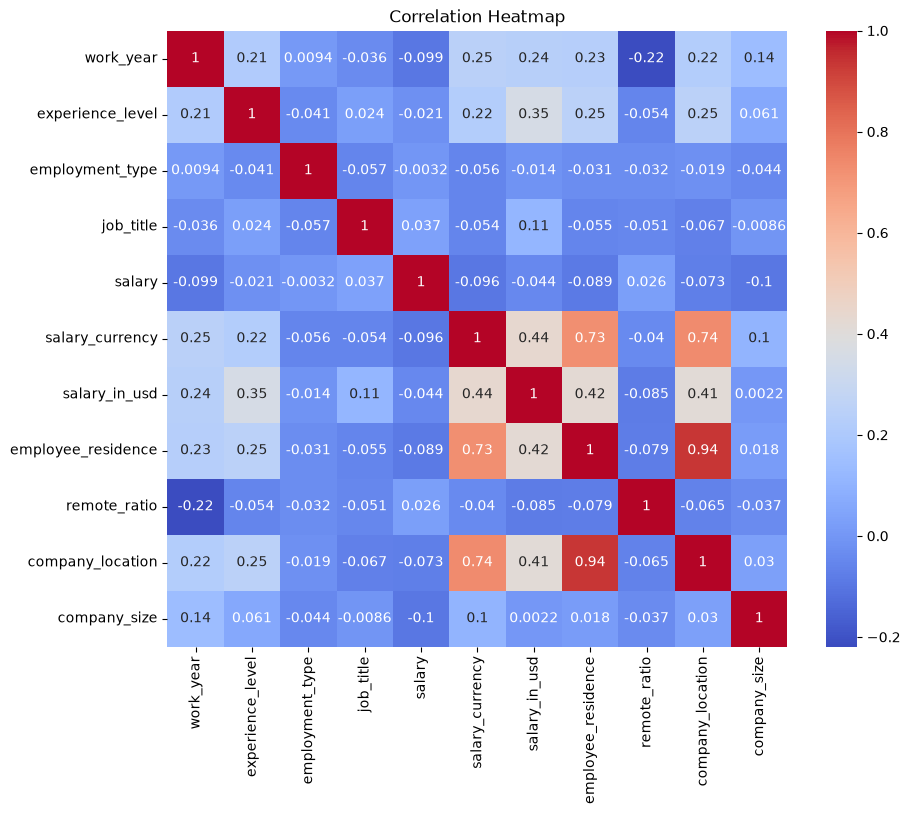

In [167]:
plt.figure(figsize=(10,8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [168]:
# Input Features
X = df.drop("salary_in_usd", axis=1)

# Target Variable
y = df["salary_in_usd"]

In [169]:


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data :", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data : (2067, 10)
Testing Data : (517, 10)


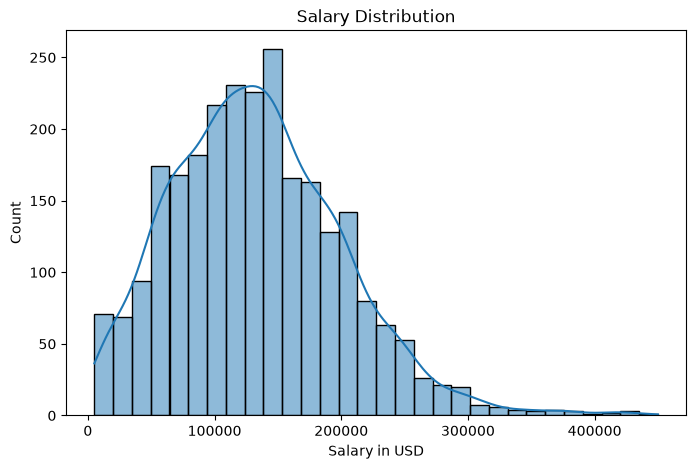

In [170]:
plt.figure(figsize=(8,5))
sns.histplot(df["salary_in_usd"], bins=30, kde=True)

plt.title("Salary Distribution")
plt.xlabel("Salary in USD")
plt.ylabel("Count")

plt.show()

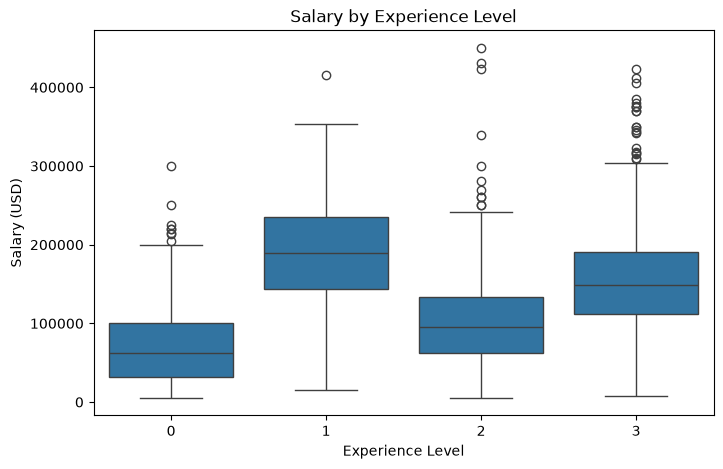

In [171]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="experience_level",
    y="salary_in_usd",
    data=df
)

plt.title("Salary by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Salary (USD)")

plt.show()

In [172]:
# Random Forest
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Gradient Boosting
gb = GradientBoostingRegressor(
    random_state=42
)

# Extra Trees
et = ExtraTreesRegressor(
    n_estimators=100,
    random_state=42
)

# AdaBoost
ada = AdaBoostRegressor(
    random_state=42
)

In [173]:
print("Training Models...\n")

rf.fit(X_train, y_train)
gb.fit(X_train, y_train)
et.fit(X_train, y_train)
ada.fit(X_train, y_train)

print("All Models Trained Successfully")

Training Models...

All Models Trained Successfully


In [174]:
rf_pred = rf.predict(X_test)

gb_pred = gb.predict(X_test)

et_pred = et.predict(X_test)

ada_pred = ada.predict(X_test)

In [175]:
def evaluate_model(name, actual, predicted):

    mae = mean_absolute_error(actual, predicted)

    mse = mean_squared_error(actual, predicted)

    rmse = np.sqrt(mse)

    r2 = r2_score(actual, predicted)

    print("\n" + "="*40)

    print("Model :", name)

    print("="*40)

    print("Mean Absolute Error :", round(mae,2))

    print("Mean Squared Error :", round(mse,2))

    print("Root Mean Squared Error :", round(rmse,2))

    print("R2 Score :", round(r2,4))

    return r2

In [176]:
rf_r2 = evaluate_model("Random Forest", y_test, rf_pred)

gb_r2 = evaluate_model("Gradient Boosting", y_test, gb_pred)

et_r2 = evaluate_model("Extra Trees", y_test, et_pred)

ada_r2 = evaluate_model("AdaBoost", y_test, ada_pred)


Model : Random Forest
Mean Absolute Error : 2011.85
Mean Squared Error : 201799961.48
Root Mean Squared Error : 14205.63
R2 Score : 0.9539

Model : Gradient Boosting
Mean Absolute Error : 2905.01
Mean Squared Error : 287547391.33
Root Mean Squared Error : 16957.22
R2 Score : 0.9343

Model : Extra Trees
Mean Absolute Error : 2475.42
Mean Squared Error : 215556986.33
Root Mean Squared Error : 14681.86
R2 Score : 0.9507

Model : AdaBoost
Mean Absolute Error : 11396.59
Mean Squared Error : 412362529.77
Root Mean Squared Error : 20306.71
R2 Score : 0.9057


In [177]:
comparison = pd.DataFrame({

    "Model":[
        "Random Forest",
        "Gradient Boosting",
        "Extra Trees",
        "AdaBoost"
    ],

    "R2 Score":[
        rf_r2,
        gb_r2,
        et_r2,
        ada_r2
    ]

})

print(comparison)

               Model  R2 Score
0      Random Forest  0.953865
1  Gradient Boosting  0.934261
2        Extra Trees  0.950719
3           AdaBoost  0.905726


In [178]:
best_model = comparison.loc[
    comparison["R2 Score"].idxmax()
]

print("\nBest Model")

print(best_model)


Best Model
Model       Random Forest
R2 Score         0.953865
Name: 0, dtype: object


In [179]:
#comparison of ensemble models

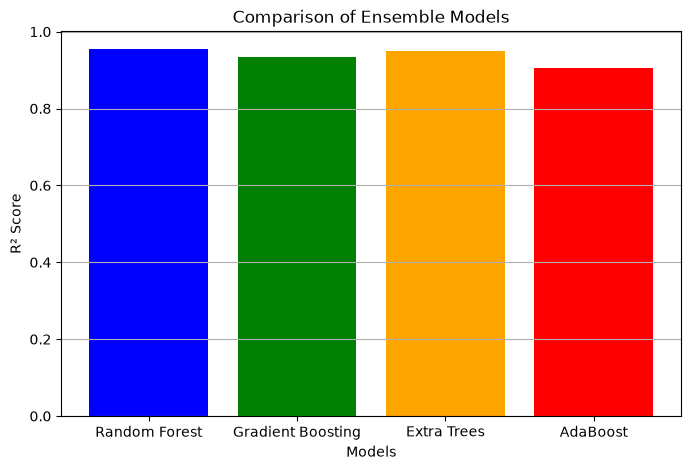

In [180]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["R2 Score"],
    color=["blue","green","orange","red"]
)

plt.title("Comparison of Ensemble Models")

plt.xlabel("Models")

plt.ylabel("R² Score")

plt.grid(axis="y")

plt.show()

In [181]:
print("="*40)
print("Best Ensemble Model")
print("="*40)

print(best_model["Model"])
print("R² Score :", best_model["R2 Score"])

Best Ensemble Model
Random Forest
R² Score : 0.9538645072637933


In [182]:
results = pd.DataFrame({
    "Actual Salary": y_test.values,
    "Predicted Salary": rf_pred
})

results.head(10)

,Actual Salary,Predicted Salary
0,52533,54788.81
1,90000,90000.00
2,225000,225130.00
3,130000,130000.00
4,100000,100420.94
5,219535,219993.30
6,189110,188935.50
7,131752,125775.72
8,249300,249520.00
9,26005,25640.48


In [183]:
#actual vs predicted salary graph

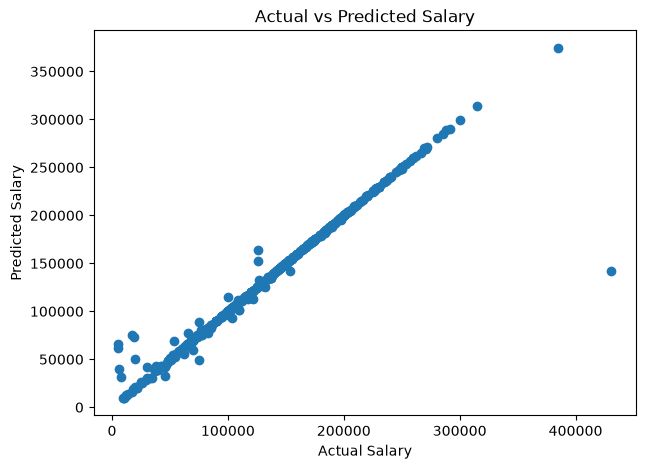

In [184]:
if best_model["Model"] == "Random Forest":
    pred = rf_pred
    final_model = rf

elif best_model["Model"] == "Gradient Boosting":
    pred = gb_pred
    final_model = gb

elif best_model["Model"] == "Extra Trees":
    pred = et_pred
    final_model = et

else:
    pred = ada_pred
    final_model = ada

plt.figure(figsize=(7,5))

plt.scatter(y_test, pred)

plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")

plt.show()

In [185]:
results["Error"] = abs(

    results["Actual Salary"]

    -

    results["Predicted Salary"]

)

results.head(10)

,Actual Salary,Predicted Salary,Error
0,52533,54788.81,2255.81
1,90000,90000.00,0.00
2,225000,225130.00,130.00
3,130000,130000.00,0.00
4,100000,100420.94,420.94
5,219535,219993.30,458.30
6,189110,188935.50,174.50
7,131752,125775.72,5976.28
8,249300,249520.00,220.00
9,26005,25640.48,364.52


In [186]:
#feature importance table

In [187]:
importance = final_model.feature_importances_

feature = pd.DataFrame({

    "Feature": X.columns,

    "Importance": importance

})

feature = feature.sort_values(
    by="Importance",
    ascending=False
)

print(feature)

              Feature  Importance
4              salary    0.857651
5     salary_currency    0.120888
8    company_location    0.006563
6  employee_residence    0.005647
3           job_title    0.003983
0           work_year    0.002325
1    experience_level    0.001144
9        company_size    0.000755
2     employment_type    0.000619
7        remote_ratio    0.000425


In [188]:
#top important features

In [189]:
feature.sort_values(
    by="Importance",
    ascending=False
).head(10)

,Feature,Importance
4,salary,0.857651
5,salary_currency,0.120888
8,company_location,0.006563
6,employee_residence,0.005647
3,job_title,0.003983
0,work_year,0.002325
1,experience_level,0.001144
9,company_size,0.000755
2,employment_type,0.000619
7,remote_ratio,0.000425


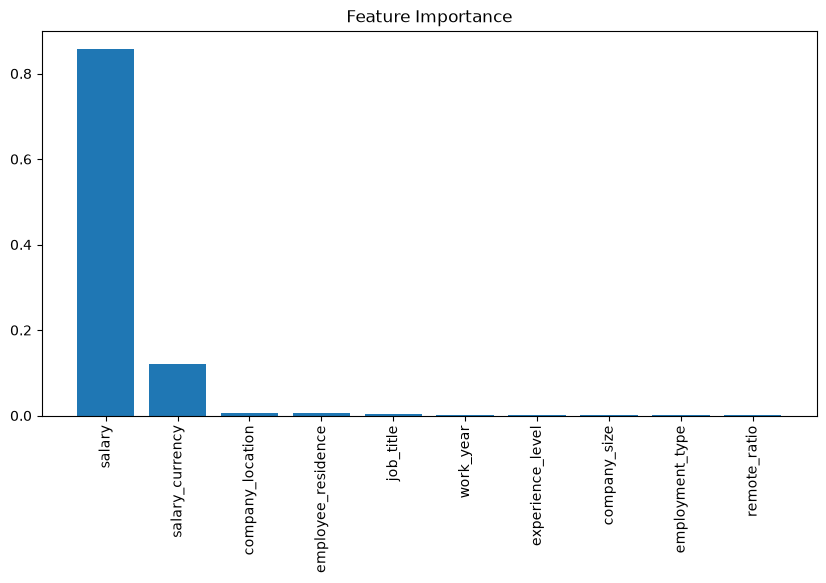

In [190]:
plt.figure(figsize=(10,5))

plt.bar(
    feature["Feature"],
    feature["Importance"]
)

plt.xticks(rotation=90)

plt.title("Feature Importance")

plt.show()

In [191]:
sample = X.iloc[[0]]

prediction = final_model.predict(sample)

print("Predicted Salary (USD):", prediction[0])

Predicted Salary (USD): 85410.92


In [192]:
#predict multiple employees
sample = X.iloc[:5]

predicted_salary = final_model.predict(sample)

pd.DataFrame({

    "Predicted Salary":predicted_salary

})

,Predicted Salary
0,85410.92
1,30462.24
2,25365.28
3,175000.00
4,120000.00
